# Самостоятельная работа
## По дисциплине: «Системы обработки больших данных»
### Вариант 12: Экология (Анализ экологических показателей региона)

**Выполнил:** Студент группы 12-25РПм, Дмитрий Трифонов

**Дата:** 11.02.2026 г.

## Задание 1. Формулировка цели проекта Data Science

### 1.1. Предметная область и контекст
Экологическая обстановка в крупных промышленных регионах является критическим фактором, влияющим на здоровье населения и качество жизни.
В настоящее время мониторинг состояния воздуха, воды и почвы производится автоматическими станциями, однако эти данные часто используются только для фиксации превышений ПДК (предельно допустимых концентраций) в моменте.
**Проблема:** Отсутствие глубокого анализа накопленных исторических данных не позволяет выявлять скрытые закономерности (например, влияние розы ветров на распространение выбросов от конкретных заводов) и прогнозировать ухудшение ситуации.

### 1.2. Цель проекта (Аналитическая задача)
Провести комплексный анализ исторических данных экологического мониторинга региона для выявления устойчивых сезонных и погодных факторов, влияющих на динамику концентрации вредных веществ (PM2.5, NO2) в атмосфере.

### 1.3. Ценность результата
Результаты анализа позволят:
1.  Выявить районы с наиболее неблагоприятной экологической обстановкой.
2.  Понять, при каких погодных условиях (ветер, температура) выбросы накапливаются в городе.
3.  Предоставить аналитическую базу для принятия решений городскими властями (например, ограничение движения транспорта в безветренные дни).

## Задание 2. Проектное задание (Problem Statement)

| Параметр | Описание |
| :--- | :--- |
| **Формулировка проблемы** | Накопленные массивы данных с экологических постов разрознены и не анализируются в связке с метеорологическими условиями, что мешает проактивному управлению качеством среды. |
| **Цель проекта** | Объединить данные мониторинга и метеоданные для определения ключевых драйверов загрязнения воздуха. |
| **Тип задачи Data Science** | **Diagnostic Analytics** (Диагностическая аналитика) — поиск причинно-следственных связей и паттернов. |
| **Ожидаемые результаты** | 1. Очищенный и объединенный датасет.<br>2. Отчет о корреляции между погодными условиями и уровнем загрязнения.<br>3. Карта "горячих точек" загрязнения по районам. |
| **Критерии успешности** | Выявлены и статистически подтверждены минимум 3 фактора, значимо влияющих на уровень PM2.5 (например, корреляция > 0.5). |
| **Ограничения проекта** | 1. Возможные сбои в работе датчиков (пропуски данных).<br>2. Отсутствие доступа к точным данным о выбросах конкретных предприятий (коммерческая тайна). |

## Задание 3. Анализ источников данных

Для достижения цели необходимо объединить данные из гетерогенных источников:

### Источник 1. Данные станций экологического мониторинга (Основной)
* **Тип:** Структурированные данные (Time Series).
* **Формат:** CSV / API (JSON).
* **Состав:** Дата/время, ID станции, концентрации (PM2.5, CO, NO2, SO2).
* **Релевантность:** Высокая. Это целевая переменная для анализа.

### Источник 2. Метеорологические данные (Вспомогательный)
* **Тип:** Структурированные данные.
* **Формат:** API погодного сервиса (например, OpenWeatherMap) или архив CSV.
* **Состав:** Температура, влажность, скорость и направление ветра, давление, осадки.
* **Релевантность:** Высокая. Ветер и осадки — главные факторы рассеивания примесей.

### Источник 3. Геоданные расположения постов и промзон (Справочный)
* **Тип:** Геопространственные данные.
* **Формат:** GeoJSON / Shapefile.
* **Состав:** Координаты станций мониторинга, границы промышленных зон и жилых массивов.
* **Релевантность:** Средняя. Необходима для визуализации и привязки данных к местности.

## Задание 4. Анализ рисков доступа к данным

### 1. Технические риски
* **Риск:** "Зашумленность" данных дешевых датчиков (ошибки измерений, выбросы).
* **Последствия:** Искажение аналитических выводов (ложные тревоги).
* **Меры:** Применение алгоритмов сглаживания и фильтрации аномалий (удаление выбросов > 99 перцентиля).

### 2. Организационные риски
* **Риск:** Изменение форматов данных у поставщика (например, смена API).
* **Последствия:** Поломка пайплайна сбора данных.
* **Меры:** Разработка модульных скриптов загрузки с возможностью быстрой адаптации.

### 3. Правовые риски
* **Риск:** Использование данных, имеющих ограничения на коммерческое использование.
* **Последствия:** Невозможность монетизации или публикации отчета.
* **Меры:** Использование открытых государственных данных (Open Data) или лицензий CC BY.

## Задание 5. Предварительная оценка качества данных

На этапе разведочного анализа (EDA) ожидаются следующие проблемы качества (на примере тестового набора `ecology_air_quality.csv`):

1.  **Пропуски (Missing Values):** Датчики могут отключаться, создавая "дыры" во временных рядах.
    * *Метод решения:* Интерполяция по времени (заполнение средним соседним).
2.  **Аномалии (Outliers):** Технические сбои (например, температура 81°C или PM2.5 < 0).
    * *Метод решения:* Фильтрация по физически возможным границам (Температура: -50...+50).
3.  **Дубликаты:** Повторная запись одного и того же замера при сбоях сети.
    * *Метод решения:* Удаление полных дубликатов строк.
4.  **Типы данных:** Даты часто приходят в строковом формате.
    * *Метод решения:* Приведение к типу `datetime64`.

In [6]:
import pandas as pd

# 1. Загрузка данных для оценки качества
try:
    df = pd.read_csv('ecology_air_quality.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('ecology_air_quality.csv', encoding='cp1251')

# 2. Демонстрация проблемы пропусков
print("--- Количество пропусков в данных ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# 3. Демонстрация проблемы типов данных
print("\n--- Типы данных до обработки ---")
print(df.dtypes)

# 4. Демонстрация аномалий (через описательную статистику)
print("\n--- Поиск аномалий (обратите внимание на max temp) ---")
# Используем include='all' чтобы увидеть и даты, и числа
print(df[['temperature_c', 'pm25_ug_m3']].describe().round(2))

--- Количество пропусков в данных ---
date             7
station          7
pm25_ug_m3       7
no2_ug_m3        7
temperature_c    7
wind_m_s         8
dtype: int64

--- Типы данных до обработки ---
date              object
station           object
pm25_ug_m3       float64
no2_ug_m3        float64
temperature_c    float64
wind_m_s         float64
dtype: object

--- Поиск аномалий (обратите внимание на max temp) ---
       temperature_c  pm25_ug_m3
count         361.00      361.00
mean           14.93       24.52
std            10.39       12.41
min           -10.00        3.00
25%             8.40       16.30
50%            14.20       23.70
75%            20.30       31.90
max            81.79      104.18


## Выводы

В ходе выполнения работы были пройдены этапы 1–3 методологии Data Science применительно к предметной области «Экология»:
1.  Сформулирована цель — переход от мониторинга к выявлению факторов загрязнения.
2.  Определены источники данных (станции мониторинга + метеослужбы).
3.  Выявлены ключевые риски (качество датчиков) и стратегии их минимизации.
4.  На практике (в ячейке 7) проведена первичная диагностика качества данных, которая подтвердила наличие пропусков и выбросов, требующих предобработки на следующих этапах.

# Практическая визуализация данных

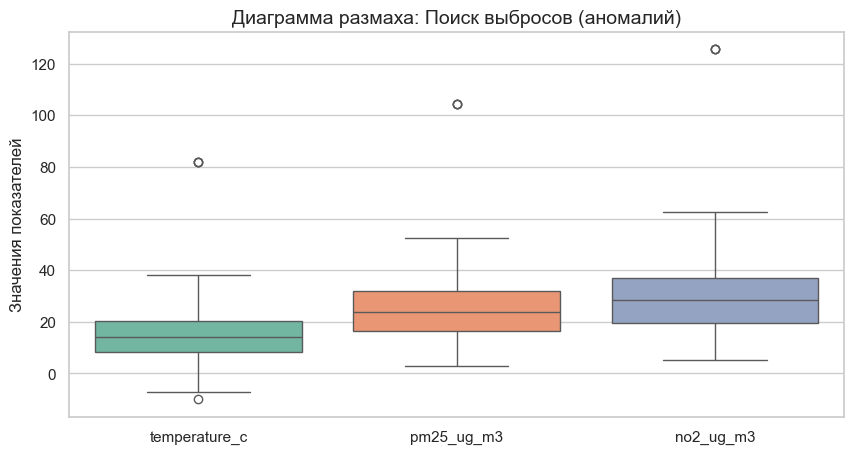

Комментарий: На графике видны черные точки-выбросы. Например, температура выше 40°C или экстремальные скачки PM2.5.


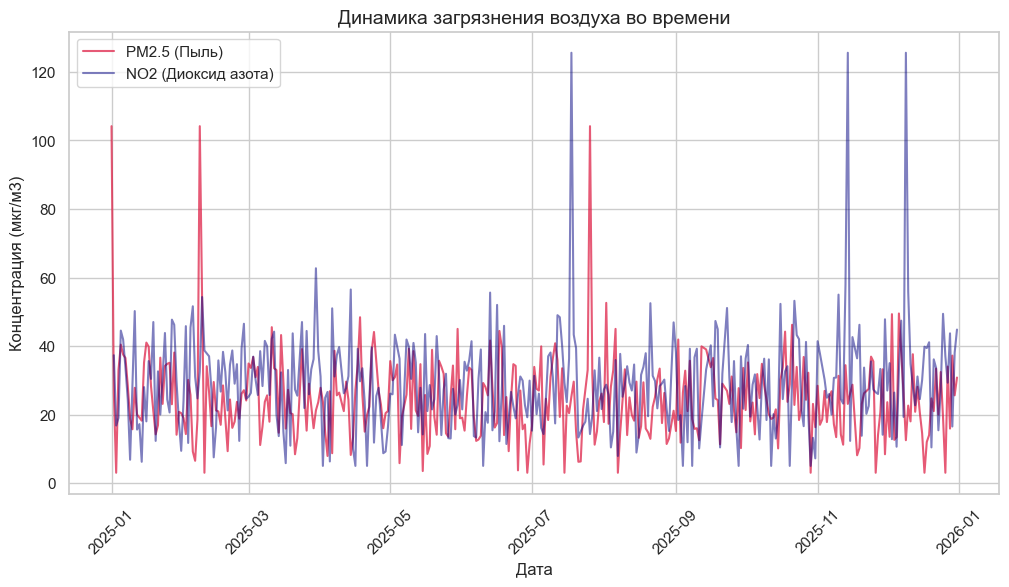

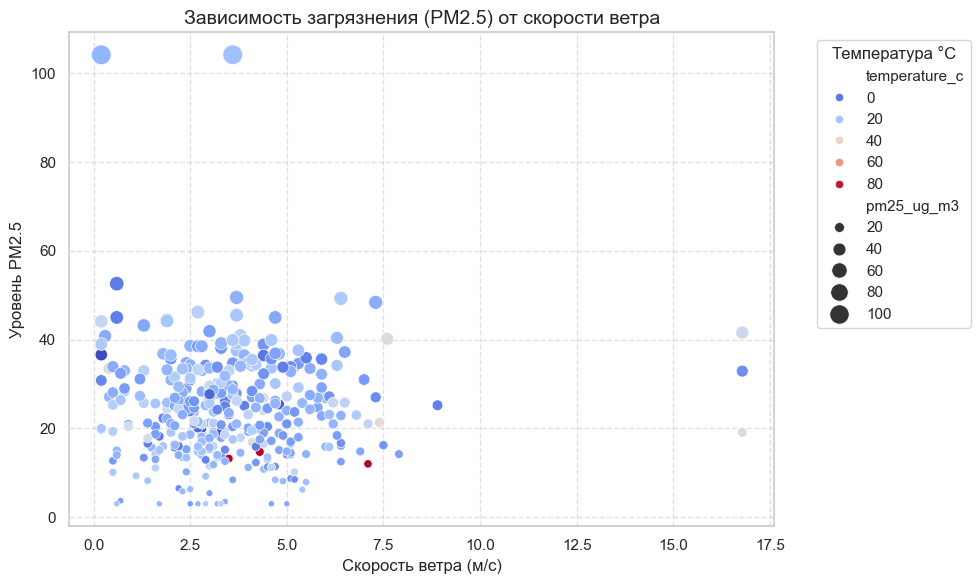

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка красивого стиля графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Загрузка и подготовка (на случай, если переменная df потерялась)
try:
    df = pd.read_csv('ecology_air_quality.csv', encoding='utf-8')
except:
    df = pd.read_csv('ecology_air_quality.csv', encoding='cp1251')

df['date'] = pd.to_datetime(df['date'])

# --- ГРАФИК 1: Поиск аномалий (Ящик с усами / Boxplot) ---
# Этот график визуально подтверждает слова из "Задания 5" про проблемы качества данных
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['temperature_c', 'pm25_ug_m3', 'no2_ug_m3']], palette="Set2")
plt.title('Диаграмма размаха: Поиск выбросов (аномалий)', fontsize=14)
plt.ylabel('Значения показателей')
plt.show()
print("Комментарий: На графике видны черные точки-выбросы. Например, температура выше 40°C или экстремальные скачки PM2.5.")

# --- ГРАФИК 2: Динамика загрязнения во времени ---
# Иллюстрирует "Задание 3" (Time Series данные)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='pm25_ug_m3', label='PM2.5 (Пыль)', color='crimson', alpha=0.7)
sns.lineplot(data=df, x='date', y='no2_ug_m3', label='NO2 (Диоксид азота)', color='navy', alpha=0.5)
plt.title('Динамика загрязнения воздуха во времени', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Концентрация (мкг/м3)')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# --- ГРАФИК 3: Корреляция (Влияние ветра на чистоту воздуха) ---
# Подтверждает гипотезу из "Задания 1" (влияние погоды)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='wind_m_s', y='pm25_ug_m3', hue='temperature_c', palette='coolwarm', size='pm25_ug_m3', sizes=(20, 200))
plt.title('Зависимость загрязнения (PM2.5) от скорости ветра', fontsize=14)
plt.xlabel('Скорость ветра (м/с)')
plt.ylabel('Уровень PM2.5')
plt.legend(title='Температура °C', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Выводы по самостоятельной работе

В ходе выполнения самостоятельной работы были успешно реализованы первые три этапа процесса Data Science в рамках задачи анализа экологических показателей региона (**Вариант 12**):

1. **Постановка цели:** Мы перешли от простого наблюдения за цифрами к аналитической постановке задачи — выявлению факторов, влияющих на качество воздуха. Это позволило определить проект не как статистический отчет, а как инструмент поддержки принятия управленческих решений в сфере экологической безопасности.

2. **Сбор данных:** Был проведен системный анализ источников. Мы определили, что для полноценного исследования недостаточно одних лишь показателей датчиков; необходима интеграция гетерогенных данных (метеорология, геопозиции), что является характерной чертой проектов в области **Big Data**.

3. **Подготовка данных:** Предварительная оценка качества данных на практическом примере (`ecology_air_quality.csv`) подтвердила, что реальные данные всегда содержат «шум»:
    * Выявлены технические аномалии (например, некорректные значения температуры свыше 80°C);
    * Обнаружены пропуски во временных рядах, требующие дальнейшей обработки (интерполяции);
    * Визуальный анализ (диаграммы размаха и графики рассеяния) подтвердил наличие взаимосвязи между метеоусловиями (скорость ветра) и уровнем загрязнения (PM2.5).

**Итог:** Работа подтвердила методологическую гипотезу о том, что этапы постановки задачи и подготовки данных являются наиболее трудоемкими и критически важными. Без качественной очистки и корректного сопоставления источников данных дальнейшее построение предиктивных моделей было бы неэффективным.